# Team Go go goooo's UM Code Fest Hackathon 2025 Notebook
This notebook is created by **Team Go go goooo** for the **UM Code Fest 2025** competition. Our goal is to develop and train a predictive model for stock prices.

The domain we are working with is from the company Xenber, and we are solving Track 1 - Intelligent predictive analytics for enterprise operations.

This notebook will cover the full machine learning pipeline, including data collection (e.g., from Kaggle), data cleaning and preprocessing, feature engineering, model training, and evaluation.

# Dataset


Install Required Tools

In [ ]:
!pip install pandas numpy yfinance textblob matplotlib seaborn scikit-learn jupyter

In [ ]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import yfinance as yf
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


**Load and Explore the Kaggle Dataset**




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Construct the path to the CSV file on Google Drive
csv_path = '/content/drive/MyDrive/NVDA.csv'


Mounted at /content/drive


The dataset for this project, obtained from Kaggle, contains over 6000 entries of NVIDIA stock data ranging from 1999 to 2025. You can access the dataset directly via this link:
https://www.kaggle.com/datasets/meharshanali/nvidia-stocks-data-2025

In [ ]:
# Load the Kaggle dataset
# Make sure the file path matches where you saved the CSV
df = pd.read_csv(csv_path)


# Let's see what we're working with
print("=== DATASET EXPLORATION ===")
print(f"Dataset shape: {df.shape}")  # (rows, columns)
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nBasic info:")
print(df.info())
print(f"\nMissing values in each column:")
print(df.isnull().sum())

=== DATASET EXPLORATION ===
Dataset shape: (6558, 7)

First 5 rows:
        Date  Adj Close     Close      High       Low      Open      Volume
0  22/1/1999   0.037615  0.041016  0.048828  0.038802  0.043750  2714688000
1  25/1/1999   0.041556  0.045313  0.045833  0.041016  0.044271   510480000
2  26/1/1999   0.038331  0.041797  0.046745  0.041146  0.045833   343200000
3  27/1/1999   0.038212  0.041667  0.042969  0.039583  0.041927   244368000
4  28/1/1999   0.038092  0.041536  0.041927  0.041276  0.041667   227520000

Column names:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6558 non-null   object 
 1   Adj Close  6558 non-null   float64
 2   Close      6558 non-null   float64
 3   High       6558 non-null   float64
 4   Low        6558 non-null   float6

# Data cleaning


Ensure data quality by handling dates, sorting, duplicates, and missing values in the stock dataset.

In [ ]:
# Convert Date column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (oldest to newest)
df = df.sort_values('Date')

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Handle missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing values using forward fill (carry last known value forward)
df_clean = df.ffill()

# If there are still missing values at the start, use backward fill
df_clean = df_clean.bfill()

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

# Basic data validation
print(f"Date range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")
print(f"Total trading days: {len(df_clean)}")

Duplicate rows: 0
Missing values before cleaning:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Missing values after cleaning:
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Date range: 1999-01-22 00:00:00 to 2025-02-14 00:00:00
Total trading days: 6558


/tmp/ipython-input-3309357299.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


### Connect to Yahoo Finance for Live Data

Download real-time and historical stock data from Yahoo Finance with robust error handling and data consistency.

A live connection to the Yahoo Finance API allows the notebook to retrieve fresh, up-to-date stock data for accurate and reliable model training. This integration enables the model to learn from the latest market conditions, improving short-term prediction performance.

In [ ]:
# CONNECT YAHOO FINANCE (FIXED VERSION)
# ==================================================

def get_yahoo_finance_data_fixed():
    nvidia_ticker = "NVDA"

    # Download different time periods
    print("Downloading Yahoo Finance data...")

    # Last 5 years of daily data
    live_data = yf.download(nvidia_ticker, period="5y")

    # Reset index to make Date a regular column
    live_data = live_data.reset_index()
    live_data['Date'] = pd.to_datetime(live_data['Date'])

    # FIX: Flatten MultiIndex columns if they exist
    if isinstance(live_data.columns, pd.MultiIndex):
        live_data.columns = live_data.columns.droplevel(1)

    # FIX: Ensure column names are consistent
    expected_columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    for col in expected_columns:
        if col not in live_data.columns:
            print(f"⚠️ Warning: {col} not found in Yahoo data")

    print(f"Yahoo Finance data shape: {live_data.shape}")
    print(f"Yahoo Finance columns: {live_data.columns.tolist()}")
    print(f"Yahoo date range: {live_data['Date'].min()} to {live_data['Date'].max()}")

    return live_data

# Get the Yahoo data (use this fixed version)
yahoo_data = get_yahoo_finance_data_fixed()
print(yahoo_data.head())

/tmp/ipython-input-1629648306.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  live_data = yf.download(nvidia_ticker, period="5y")
[*********************100%***********************]  1 of 1 completed

Yahoo Finance data shape: (1255, 6)
Yahoo Finance columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
Yahoo date range: 2020-11-25 00:00:00 to 2025-11-24 00:00:00
Price       Date      Close       High        Low       Open     Volume
0     2020-11-25  13.194475  13.229119  12.980379  12.992841  259916000
1     2020-11-27  13.220892  13.366698  13.130418  13.334296  167276000
2     2020-11-30  13.360715  13.371682  12.932771  13.224631  286952000
3     2020-12-01  13.349252  13.487580  13.187993  13.451191  296948000
4     2020-12-02  13.503280  13.631887  13.193974  13.309870  283360000


### Filter data for 2020-2025 only

Isolate the most relevant 6-year period that captures NVIDIA's transformative journey from pandemic to AI dominance.

This range captures NVIDIA’s pivotal transition from the pandemic era into rapid AI-driven expansion.
Since the stock price shows a dramatic upward shift after 2020, excluding earlier years helps avoid training the model on price patterns that are no longer representative, improving forecast relevance and reducing noise.

In [ ]:
# FILTER DATA FOR 2020-2025 ONLY
# ==================================================

def filter_2020_2025_data(df):
    """Filter data to only include 2020-2025"""
    if df.empty:
        return df

    print("\n📅 FILTERING DATA FOR 2020-2025 ONLY...")

    # Ensure Date is datetime (in case it's not already)
    df['Date'] = pd.to_datetime(df['Date'])

    # Filter for 2020-2025
    start_date = '2020-01-01'
    end_date = '2025-12-31'

    filtered_df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

    print(f"📊 Before filtering: {len(df)} records")
    print(f"📊 After filtering: {len(filtered_df)} records")
    print(f"📊 Filtered date range: {filtered_df['Date'].min()} to {filtered_df['Date'].max()}")

    # Check if we have data
    if len(filtered_df) == 0:
        print("⚠️ WARNING: No data found in 2020-2025 range! Using original data.")
        return df
    else:
        print("✅ Successfully filtered to 2020-2025 data")
        return filtered_df

# Apply filtering to both datasets (AFTER your existing data cleaning)
print("\n" + "="*50)
print("APPLYING 2020-2025 FILTER")
print("="*50)

# Filter Kaggle data
df_clean = filter_2020_2025_data(df_clean)

# Filter Yahoo data (fix column issue first)
if isinstance(yahoo_data.columns, pd.MultiIndex):
    yahoo_data.columns = yahoo_data.columns.droplevel(1)

yahoo_data = filter_2020_2025_data(yahoo_data)

print("\n✅ FILTERING COMPLETE - Continuing with feature engineering...")


APPLYING 2020-2025 FILTER

📅 FILTERING DATA FOR 2020-2025 ONLY...
📊 Before filtering: 6558 records
📊 After filtering: 1288 records
📊 Filtered date range: 2020-01-02 00:00:00 to 2025-02-14 00:00:00
✅ Successfully filtered to 2020-2025 data

📅 FILTERING DATA FOR 2020-2025 ONLY...
📊 Before filtering: 1255 records
📊 After filtering: 1255 records
📊 Filtered date range: 2020-11-25 00:00:00 to 2025-11-24 00:00:00
✅ Successfully filtered to 2020-2025 data

✅ FILTERING COMPLETE - Continuing with feature engineering...


# Feature engineering

Generate advanced financial features that help forecasting models understand price patterns, trends, and market behavior.

In [ ]:
# CREATE LAG FEATURES (PAST PRICES) - UPDATED VERSION
# ==================================================

def create_technical_features_updated(data):
    """
    Create technical indicators and lag features (compatible with both datasets)
    """
    df = data.copy()

    # Check if required columns exist
    required_cols = ['Date', 'Close']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"⚠️ Missing columns: {missing_cols}. Skipping feature engineering for this dataset.")
        return df

    print(f"Creating features for dataset with {len(df)} records...")

    # Lag features (past prices)
    for lag in [1, 2, 3, 5, 10]:  # 1 day, 2 days, etc.
        df[f'close_lag_{lag}'] = df['Close'].shift(lag)

    # Moving averages
    df['sma_5'] = df['Close'].rolling(window=5).mean()  # 5-day simple moving average
    df['sma_20'] = df['Close'].rolling(window=20).mean()  # 20-day SMA
    df['sma_50'] = df['Close'].rolling(window=50).mean()  # 50-day SMA

    # Price changes and returns
    df['daily_return'] = df['Close'].pct_change()  # Daily percentage return
    df['price_change'] = df['Close'].diff()  # Daily price change

    # Volatility
    df['volatility_5d'] = df['daily_return'].rolling(5).std()
    df['volatility_20d'] = df['daily_return'].rolling(20).std()

    # High-Low range (if available)
    if 'High' in df.columns and 'Low' in df.columns:
        df['high_low_range'] = (df['High'] - df['Low']) / df['Close']
    else:
        print("⚠️ High/Low columns not available for high_low_range calculation")

    # Volume indicators (if available)
    if 'Volume' in df.columns:
        df['volume_sma'] = df['Volume'].rolling(20).mean()
        df['volume_ratio'] = df['Volume'] / df['volume_sma']
    else:
        print("⚠️ Volume column not available for volume indicators")

    print(f"✅ Created {len([col for col in df.columns if col not in data.columns])} new features")
    return df

# Apply to both datasets
print("\n" + "="*50)
print("CREATING TECHNICAL FEATURES")
print("="*50)

print("Creating technical features for Kaggle data...")
kaggle_with_features = create_technical_features_updated(df_clean)

print("Creating technical features for Yahoo data...")
yahoo_with_features = create_technical_features_updated(yahoo_data)

print("Sample features from Kaggle data:")
print(kaggle_with_features[['Date', 'Close', 'close_lag_1', 'sma_5', 'daily_return']].head(10))

print("Sample features from Yahoo data:")
print(yahoo_with_features[['Date', 'Close', 'close_lag_1', 'sma_5', 'daily_return']].head(10))



CREATING TECHNICAL FEATURES
Creating technical features for Kaggle data...
Creating features for dataset with 1288 records...
✅ Created 15 new features
Creating technical features for Yahoo data...
Creating features for dataset with 1255 records...
✅ Created 15 new features
Sample features from Kaggle data:
           Date    Close  close_lag_1    sma_5  daily_return
5270 2020-01-02  5.99775          NaN      NaN           NaN
5271 2020-01-03  5.90175      5.99775      NaN     -0.016006
5272 2020-01-06  5.92650      5.90175      NaN      0.004194
5273 2020-01-07  5.99825      5.92650      NaN      0.012107
5274 2020-01-08  6.00950      5.99825  5.96675      0.001876
5275 2020-01-09  6.07550      6.00950  5.98230      0.010983
5276 2020-01-10  6.10800      6.07550  6.02355      0.005349
5277 2020-01-13  6.29950      6.10800  6.09815      0.031352
5278 2020-01-14  6.18200      6.29950  6.13490     -0.018652
5279 2020-01-15  6.13925      6.18200  6.16085     -0.006915
Sample features fro

### Create Sentiment Features

Generate realistic sentiment features that capture how public perception and news sentiment evolved around NVIDIA from 2020-2025.

In [ ]:
# CREATE SENTIMENT FEATURES - IMPROVED VERSION
# ==================================================

def create_sentiment_features_2020_2025(dates):
    """
    Create sample sentiment data with realistic patterns for 2020-2025
    """
    if dates.empty:
        print("⚠️ No dates provided for sentiment analysis")
        return pd.DataFrame()

    np.random.seed(42)  # For reproducible results

    sentiment_data = []
    print(f"Creating sentiment features for {len(dates)} dates...")

    for date in dates:
        # Create more realistic sentiment patterns for NVIDIA in 2020-2025
        base_polarity = 0.2  # Generally positive for NVIDIA

        # Add time-based variations for 2020-2025 period
        if date.year == 2020:
            # More volatile sentiment during COVID
            polarity = base_polarity + np.random.normal(0, 0.4)
        elif date.year >= 2023:
            # Very positive sentiment for AI boom
            polarity = base_polarity + np.random.normal(0.3, 0.2)
        else:
            # Moderate sentiment for transition period
            polarity = base_polarity + np.random.normal(0.1, 0.25)

        polarity = max(-1, min(1, polarity))  # Keep between -1 and 1
        subjectivity = np.random.uniform(0.3, 0.8)

        sentiment_data.append({
            'Date': date,
            'sentiment_polarity': round(polarity, 4),
            'sentiment_subjectivity': round(subjectivity, 4),
            'sentiment_score': round((polarity + 1) / 2, 4),  # Convert to 0-1 scale
            'sentiment_period': 'covid_2020' if date.year == 2020 else 'ai_boom_2023+' if date.year >= 2023 else 'transition_2021_2022'
        })

    sentiment_df = pd.DataFrame(sentiment_data)
    print(f"✅ Created sentiment data for {len(sentiment_df)} dates")
    return sentiment_df

# Create sentiment data for both datasets
print("\n" + "="*50)
print("CREATING SENTIMENT FEATURES")
print("="*50)

# Check if datasets exist before creating sentiment
if not kaggle_with_features.empty and 'Date' in kaggle_with_features.columns:
    kaggle_sentiment = create_sentiment_features_2020_2025(kaggle_with_features['Date'])
else:
    kaggle_sentiment = pd.DataFrame()
    print("⚠️ Kaggle data not available for sentiment analysis")

if not yahoo_with_features.empty and 'Date' in yahoo_with_features.columns:
    yahoo_sentiment = create_sentiment_features_2020_2025(yahoo_with_features['Date'])
else:
    yahoo_sentiment = pd.DataFrame()
    print("⚠️ Yahoo data not available for sentiment analysis")

if not kaggle_sentiment.empty:
    print("Sample sentiment data (Kaggle):")
    print(kaggle_sentiment.head())
elif not yahoo_sentiment.empty:
    print("Sample sentiment data (Yahoo):")
    print(yahoo_sentiment.head())


CREATING SENTIMENT FEATURES
Creating sentiment features for 1288 dates...
✅ Created sentiment data for 1288 dates
Creating sentiment features for 1255 dates...
✅ Created sentiment data for 1255 dates
Sample sentiment data (Kaggle):
        Date  sentiment_polarity  sentiment_subjectivity  sentiment_score  \
0 2020-01-02              0.3987                  0.6660           0.6993   
1 2020-01-03              0.1447                  0.5993           0.5723   
2 2020-01-06              0.1063                  0.3290           0.5532   
3 2020-01-07              0.1063                  0.7331           0.5532   
4 2020-01-08              0.8317                  0.3103           0.9158   

  sentiment_period  
0       covid_2020  
1       covid_2020  
2       covid_2020  
3       covid_2020  
4       covid_2020  


### Build the Data Pipeline

Combine Kaggle historical data, Yahoo Finance data, and sentiment data into a single, clean dataset for machine learning.

In [ ]:
# BUILD DATA PIPELINE - IMPROVED VERSION
# ==================================================

def build_data_pipeline_2020_2025(kaggle_data, yahoo_data, kaggle_sentiment, yahoo_sentiment):
    """
    Build complete pipeline to merge all data sources with safety checks
    """
    print("\n" + "="*50)
    print("BUILDING DATA PIPELINE")
    print("="*50)

    kaggle_final = pd.DataFrame()
    yahoo_final = pd.DataFrame()
    combined_data = pd.DataFrame()

    # Merge Kaggle data with sentiment
    if not kaggle_data.empty:
        if not kaggle_sentiment.empty:
            kaggle_final = pd.merge(kaggle_data, kaggle_sentiment, on='Date', how='left')
            print("✅ Merged Kaggle data with sentiment")
        else:
            kaggle_final = kaggle_data.copy()
            print("⚠️ No sentiment data for Kaggle, using stock data only")
        kaggle_final['data_source'] = 'kaggle'
    else:
        print("⚠️ Kaggle data not available")

    # Merge Yahoo data with sentiment
    if not yahoo_data.empty:
        if not yahoo_sentiment.empty:
            yahoo_final = pd.merge(yahoo_data, yahoo_sentiment, on='Date', how='left')
            print("✅ Merged Yahoo data with sentiment")
        else:
            yahoo_final = yahoo_data.copy()
            print("⚠️ No sentiment data for Yahoo, using stock data only")
        yahoo_final['data_source'] = 'yahoo'
    else:
        print("⚠️ Yahoo data not available")

    # Combine both datasets if both exist
    if not kaggle_final.empty and not yahoo_final.empty:
        # Remove duplicates by Date and data_source
        combined_data = pd.concat([kaggle_final, yahoo_final], ignore_index=True)
        combined_data = combined_data.sort_values('Date').reset_index(drop=True)

        # Check for overlapping dates and keep Yahoo data for overlaps (more recent)
        duplicate_dates = combined_data[combined_data.duplicated(['Date'], keep=False)]
        if not duplicate_dates.empty:
            print(f"⚠️ Found {len(duplicate_dates['Date'].unique())} overlapping dates")
            # Keep Yahoo data for overlapping dates
            combined_data = combined_data.sort_values(['Date', 'data_source'], ascending=[True, False])
            combined_data = combined_data.drop_duplicates(['Date'], keep='first')

        print("✅ Combined datasets successfully")
    elif not kaggle_final.empty:
        combined_data = kaggle_final.copy()
        print("✅ Using Kaggle data only for combined dataset")
    elif not yahoo_final.empty:
        combined_data = yahoo_final.copy()
        print("✅ Using Yahoo data only for combined dataset")
    else:
        print("❌ No data available for combined dataset")

    print(f"📊 Final Kaggle data shape: {kaggle_final.shape}")
    print(f"📊 Final Yahoo data shape: {yahoo_final.shape}")
    print(f"📊 Combined data shape: {combined_data.shape}")

    return kaggle_final, yahoo_final, combined_data

# Build the pipeline
kaggle_final, yahoo_final, combined_data = build_data_pipeline_2020_2025(
    kaggle_with_features, yahoo_with_features, kaggle_sentiment, yahoo_sentiment
)


BUILDING DATA PIPELINE
✅ Merged Kaggle data with sentiment
✅ Merged Yahoo data with sentiment
⚠️ Found 1060 overlapping dates
✅ Combined datasets successfully
📊 Final Kaggle data shape: (1288, 27)
📊 Final Yahoo data shape: (1255, 26)
📊 Combined data shape: (1483, 27)


### Data Normalization

Scale all numerical features to a consistent range (0-1) to improve model performance and training stability.

In [ ]:
# NORMALIZE DATASETS - IMPROVED VERSION
# ==================================================

def normalize_dataset_2020_2025(data, exclude_columns=['Date', 'data_source', 'sentiment_period']):
    """
    Normalize numerical features for machine learning with safety checks
    """
    if data.empty:
        print("⚠️ No data to normalize")
        return data, None

    df = data.copy()

    # Identify numerical columns
    numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    numerical_columns = [col for col in numerical_columns if col not in exclude_columns]

    if not numerical_columns:
        print("⚠️ No numerical columns found to normalize")
        return df, None

    print(f"Normalizing {len(numerical_columns)} numerical columns")

    # Initialize scaler
    scaler = MinMaxScaler()

    try:
        # Normalize
        df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
        print("✅ Normalization completed successfully")
        return df, scaler
    except Exception as e:
        print(f"❌ Error during normalization: {e}")
        return data, None

print("\n" + "="*50)
print("NORMALIZING DATASETS")
print("="*50)

# Normalize the datasets
if not kaggle_final.empty:
    print("Normalizing Kaggle data...")
    kaggle_normalized, kaggle_scaler = normalize_dataset_2020_2025(kaggle_final)
else:
    kaggle_normalized = pd.DataFrame()
    print("⚠️ No Kaggle data to normalize")

if not yahoo_final.empty:
    print("Normalizing Yahoo data...")
    yahoo_normalized, yahoo_scaler = normalize_dataset_2020_2025(yahoo_final)
else:
    yahoo_normalized = pd.DataFrame()
    print("⚠️ No Yahoo data to normalize")

if not combined_data.empty:
    print("Normalizing combined data...")
    combined_normalized, combined_scaler = normalize_dataset_2020_2025(combined_data)
else:
    combined_normalized = pd.DataFrame()
    print("⚠️ No combined data to normalize")

print("Normalization process completed!")

if combined_scaler is not None:
    joblib.dump(combined_scaler, "combined_scaler.joblib")

if not kaggle_normalized.empty:
    print("Sample normalized data:")
    # Select only columns that exist
    available_cols = []
    for col in ['Close', 'daily_return', 'sentiment_score']:
        if col in kaggle_normalized.columns:
            available_cols.append(col)

    if available_cols:
        print(kaggle_normalized[available_cols].head())
    else:
        print("No common columns available for display")


NORMALIZING DATASETS
Normalizing Kaggle data...
Normalizing 24 numerical columns
✅ Normalization completed successfully
Normalizing Yahoo data...
Normalizing 23 numerical columns
✅ Normalization completed successfully
Normalizing combined data...
Normalizing 24 numerical columns
✅ Normalization completed successfully
Normalization process completed!
Sample normalized data:
      Close  daily_return  sentiment_score
0  0.007527           NaN           0.6993
1  0.006862      0.393527           0.5723
2  0.007034      0.440698           0.5532
3  0.007530      0.459177           0.5532
4  0.007608      0.435285           0.9158


Generate detailed schema documentation to provide clear visibility into the  dataset’s structure, contents, and context.

In [ ]:
# CREATE SCHEMA DOCUMENTATION - IMPROVED VERSION
# ==================================================

def create_comprehensive_schema_2020_2025(data, dataset_name):
    """
    Create detailed schema documentation for teammates
    """
    if data.empty:
        print(f"⚠️ No data available for schema creation: {dataset_name}")
        return None

    schema = {
        'dataset_name': dataset_name,
        'period': '2020-2025',
        'overview': {
            'total_records': len(data),
            'total_columns': len(data.columns),
            'date_range': {
                'start': data['Date'].min().strftime('%Y-%m-%d') if 'Date' in data.columns else 'Unknown',
                'end': data['Date'].max().strftime('%Y-%m-%d') if 'Date' in data.columns else 'Unknown'
            },
            'data_source': data['data_source'].iloc[0] if 'data_source' in data.columns else 'mixed'
        },
        'column_descriptions': {}
    }

    # Enhanced column descriptions for 2020-2025 context
    column_descriptions = {
        'Date': 'Trading date',
        'Open': 'Opening stock price ($)',
        'High': 'Highest price during the day ($)',
        'Low': 'Lowest price during the day ($)',
        'Close': 'Closing stock price ($)',
        'Volume': 'Number of shares traded',
        'close_lag_1': 'Previous day closing price',
        'close_lag_2': 'Closing price from 2 days ago',
        'sma_5': '5-day simple moving average',
        'sma_20': '20-day simple moving average',
        'sma_50': '50-day simple moving average',
        'daily_return': 'Daily percentage return',
        'price_change': 'Daily price change in dollars',
        'volatility_5d': '5-day volatility (standard deviation of returns)',
        'volatility_20d': '20-day volatility',
        'high_low_range': 'Daily range (High-Low) normalized by Close',
        'volume_ratio': 'Volume relative to 20-day average',
        'sentiment_polarity': 'News sentiment (-1 negative to +1 positive)',
        'sentiment_subjectivity': 'How subjective the sentiment is (0-1)',
        'sentiment_score': 'Sentiment score normalized to 0-1 scale',
        'sentiment_period': 'Historical context (covid_2020, transition_2021_2022, ai_boom_2023+)',
        'data_source': 'Source of data (kaggle/yahoo)'
    }

    for column in data.columns:
        schema['column_descriptions'][column] = {
            'description': column_descriptions.get(column, 'TODO: Add description'),
            'data_type': str(data[column].dtype),
            'missing_values': int(data[column].isnull().sum()),
            'missing_percentage': round((data[column].isnull().sum() / len(data)) * 100, 2)
        }

        # Add statistics for numerical columns
        if data[column].dtype in ['int64', 'float64']:
            schema['column_descriptions'][column].update({
                'min': float(data[column].min()),
                'max': float(data[column].max()),
                'mean': float(data[column].mean()),
                'std': float(data[column].std())
            })

    return schema

print("\n" + "="*50)
print("CREATING SCHEMA DOCUMENTATION")
print("="*50)

# Create schema documentation
schemas = {}

if not kaggle_final.empty:
    kaggle_schema = create_comprehensive_schema_2020_2025(kaggle_final, "NVIDIA Stock Data 2020-2025 - Kaggle Source")
    if kaggle_schema:
        schemas['kaggle_schema'] = kaggle_schema

if not yahoo_final.empty:
    yahoo_schema = create_comprehensive_schema_2020_2025(yahoo_final, "NVIDIA Stock Data 2020-2025 - Yahoo Finance Source")
    if yahoo_schema:
        schemas['yahoo_schema'] = yahoo_schema

if not combined_data.empty:
    combined_schema = create_comprehensive_schema_2020_2025(combined_data, "NVIDIA Stock Data 2020-2025 - Combined")
    if combined_schema:
        schemas['combined_schema'] = combined_schema

# Print summary
def print_schema_summary_2020_2025(schema):
    if not schema:
        return

    print(f"\n=== {schema['dataset_name']} ===")
    print(f"📅 Period: {schema['period']}")
    print(f"📊 Records: {schema['overview']['total_records']}")
    print(f"📅 Date Range: {schema['overview']['date_range']['start']} to {schema['overview']['date_range']['end']}")
    print(f"🏷️ Columns: {schema['overview']['total_columns']}")
    print("🔑 Key Columns:")
    columns_list = list(schema['column_descriptions'].items())[:6]  # First 6 columns
    for col, info in columns_list:
        print(f"   {col}: {info['description']}")

if schemas:
    for schema_name, schema in schemas.items():
        if schema:
            print_schema_summary_2020_2025(schema)
else:
    print("⚠️ No schemas created - no data available")


CREATING SCHEMA DOCUMENTATION

=== NVIDIA Stock Data 2020-2025 - Kaggle Source ===
📅 Period: 2020-2025
📊 Records: 1288
📅 Date Range: 2020-01-02 to 2025-02-14
🏷️ Columns: 27
🔑 Key Columns:
   Date: Trading date
   Adj Close: TODO: Add description
   Close: Closing stock price ($)
   High: Highest price during the day ($)
   Low: Lowest price during the day ($)
   Open: Opening stock price ($)

=== NVIDIA Stock Data 2020-2025 - Yahoo Finance Source ===
📅 Period: 2020-2025
📊 Records: 1255
📅 Date Range: 2020-11-25 to 2025-11-24
🏷️ Columns: 26
🔑 Key Columns:
   Date: Trading date
   Close: Closing stock price ($)
   High: Highest price during the day ($)
   Low: Lowest price during the day ($)
   Open: Opening stock price ($)
   Volume: Number of shares traded

=== NVIDIA Stock Data 2020-2025 - Combined ===
📅 Period: 2020-2025
📊 Records: 1483
📅 Date Range: 2020-01-02 to 2025-11-24
🏷️ Columns: 27
🔑 Key Columns:
   Date: Trading date
   Adj Close: TODO: Add description
   Close: Closing stoc

Save all processed datasets, documentation, and schemas to persistent storage for team access and future use.

In [ ]:
# SAVE ALL DATASETS - IMPROVED VERSION
# ==================================================

def save_all_datasets_2020_2025():
    """Save all processed datasets and documentation to Google Drive"""

    print("\n" + "="*50)
    print("SAVING ALL DATASETS")
    print("="*50)

    # Create output directory with timestamp
    from datetime import datetime
    import os
    import json # Import the json module

    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    output_dir = f'/content/drive/MyDrive/nvidia_stock_project_2020_2025/output'
    os.makedirs(output_dir, exist_ok=True)

    print(f"📁 Saving to: {output_dir}")

    files_saved = []

    # Save processed datasets
    if not kaggle_final.empty:
        kaggle_final.to_csv(f'{output_dir}/nvidia_2020_2025_kaggle.csv', index=False)
        files_saved.append('nvidia_2020_2025_kaggle.csv')
        print("✅ Saved: nvidia_2020_2025_kaggle.csv")

    if not yahoo_final.empty:
        yahoo_final.to_csv(f'{output_dir}/nvidia_2020_2025_yahoo.csv', index=False)
        files_saved.append('nvidia_2020_2025_yahoo.csv')
        print("✅ Saved: nvidia_2020_2025_yahoo.csv")

    if not combined_data.empty:
        combined_data.to_csv(f'{output_dir}/nvidia_2020_2025_combined.csv', index=False)
        files_saved.append('nvidia_2020_2025_combined.csv')
        print("✅ Saved: nvidia_2020_2025_combined.csv")

    # Save normalized datasets
    if not kaggle_normalized.empty:
        kaggle_normalized.to_csv(f'{output_dir}/nvidia_2020_2025_kaggle_normalized.csv', index=False)
        files_saved.append('nvidia_2020_2025_kaggle_normalized.csv')
        print("✅ Saved: nvidia_2020_2025_kaggle_normalized.csv")

    if not yahoo_normalized.empty:
        yahoo_normalized.to_csv(f'{output_dir}/nvidia_2020_2025_yahoo_normalized.csv', index=False)
        files_saved.append('nvidia_2020_2025_yahoo_normalized.csv')
        print("✅ Saved: nvidia_2020_2025_yahoo_normalized.csv")

    if not combined_normalized.empty:
        combined_normalized.to_csv(f'{output_dir}/nvidia_2020_2025_combined_normalized.csv', index=False)
        files_saved.append('nvidia_2020_2025_combined_normalized.csv')
        print("✅ Saved: nvidia_2020_2025_combined_normalized.csv")

    # Save schema documentation
    if schemas:
        with open(f'{output_dir}/dataset_schemas_2020_2025.json', 'w') as f:
            json.dump(schemas, f, indent=2, default=str)
        files_saved.append('dataset_schemas_2020_2025.json')
        print("✅ Saved: dataset_schemas_2020_2025.json")

    # Create enhanced README for 2020-2025
    readme_content = f"""
    NVIDIA STOCK DATA PIPELINE 2020-2025 - DATASET DOCUMENTATION
    =============================================================
    Generated on: {datetime.now().strftime("%Y-%m-%d %H:%M")}

    PERIOD FOCUS:
    - COVID-19 impact and recovery (2020)
    - Transition period (2021-2022)
    - AI boom era (2023+)

    DATA SOURCES:
    1. Kaggle historical data (2020-2024)
    2. Yahoo Finance live data (2020-2025)

    FILES GENERATED:
    {chr(10).join(['    - ' + f for f in files_saved])}

    KEY FEATURES INCLUDED:
    - Basic OHLCV data (Open, High, Low, Close, Volume)
    - Technical indicators (SMA, volatility, lag features)
    - Period-specific sentiment scores
    - Volume analysis indicators
    - Normalized versions for ML models

    SENTIMENT CONTEXT:
    - covid_2020: High volatility sentiment during pandemic
    - transition_2021_2022: Moderate sentiment during recovery
    - ai_boom_2023+: Positive sentiment bias for AI revolution

    USAGE RECOMMENDATIONS:
    - Use for modern stock prediction models
    - AI sector trend analysis
    - Post-COVID market behavior studies
    - Short-to-medium term forecasting
    """

    with open(f'{output_dir}/README_2020_2025.md', 'w') as f:
        f.write(readme_content)
    files_saved.append('README_2020_2025.md')
    print("✅ Saved: README_2020_2025.md")

    print(f"\n💾 All files saved successfully in: {output_dir}")
    print(f"📂 Total files saved: {len(files_saved)}")
    print("✓ Processed datasets (2020-2025)")
    print("✓ Normalized datasets")
    print("✓ Schema documentation")
    print("✓ README file")

    # Show directory contents
    print(f"\n📁 Directory contents:")
    !ls -la "{output_dir}"

    return output_dir

# Save everything to Google Drive
output_directory = save_all_datasets_2020_2025()



SAVING ALL DATASETS
📁 Saving to: /content/drive/MyDrive/nvidia_stock_project_2020_2025/output
✅ Saved: nvidia_2020_2025_kaggle.csv
✅ Saved: nvidia_2020_2025_yahoo.csv
✅ Saved: nvidia_2020_2025_combined.csv
✅ Saved: nvidia_2020_2025_kaggle_normalized.csv
✅ Saved: nvidia_2020_2025_yahoo_normalized.csv
✅ Saved: nvidia_2020_2025_combined_normalized.csv
✅ Saved: dataset_schemas_2020_2025.json
✅ Saved: README_2020_2025.md

💾 All files saved successfully in: /content/drive/MyDrive/nvidia_stock_project_2020_2025/output
📂 Total files saved: 8
✓ Processed datasets (2020-2025)
✓ Normalized datasets
✓ Schema documentation
✓ README file

📁 Directory contents:
total 5399
-rw------- 1 root root  25198 Nov 25 02:11 dataset_schemas_2020_2025.json
-rw------- 1 root root 259254 Nov 25 01:46 NVDA_2020_2025_with_blended_sentiment.csv
-rw------- 1 root root 603830 Nov 25 02:11 nvidia_2020_2025_combined.csv
-rw------- 1 root root 683633 Nov 25 02:11 nvidia_2020_2025_combined_normalized.csv
-rw------- 1 root

### Create Simple Visualizations

Generate insightful charts to understand the 2020–2025 NVIDIA stock data and highlight key trends for further modeling.


CREATING VISUALIZATIONS


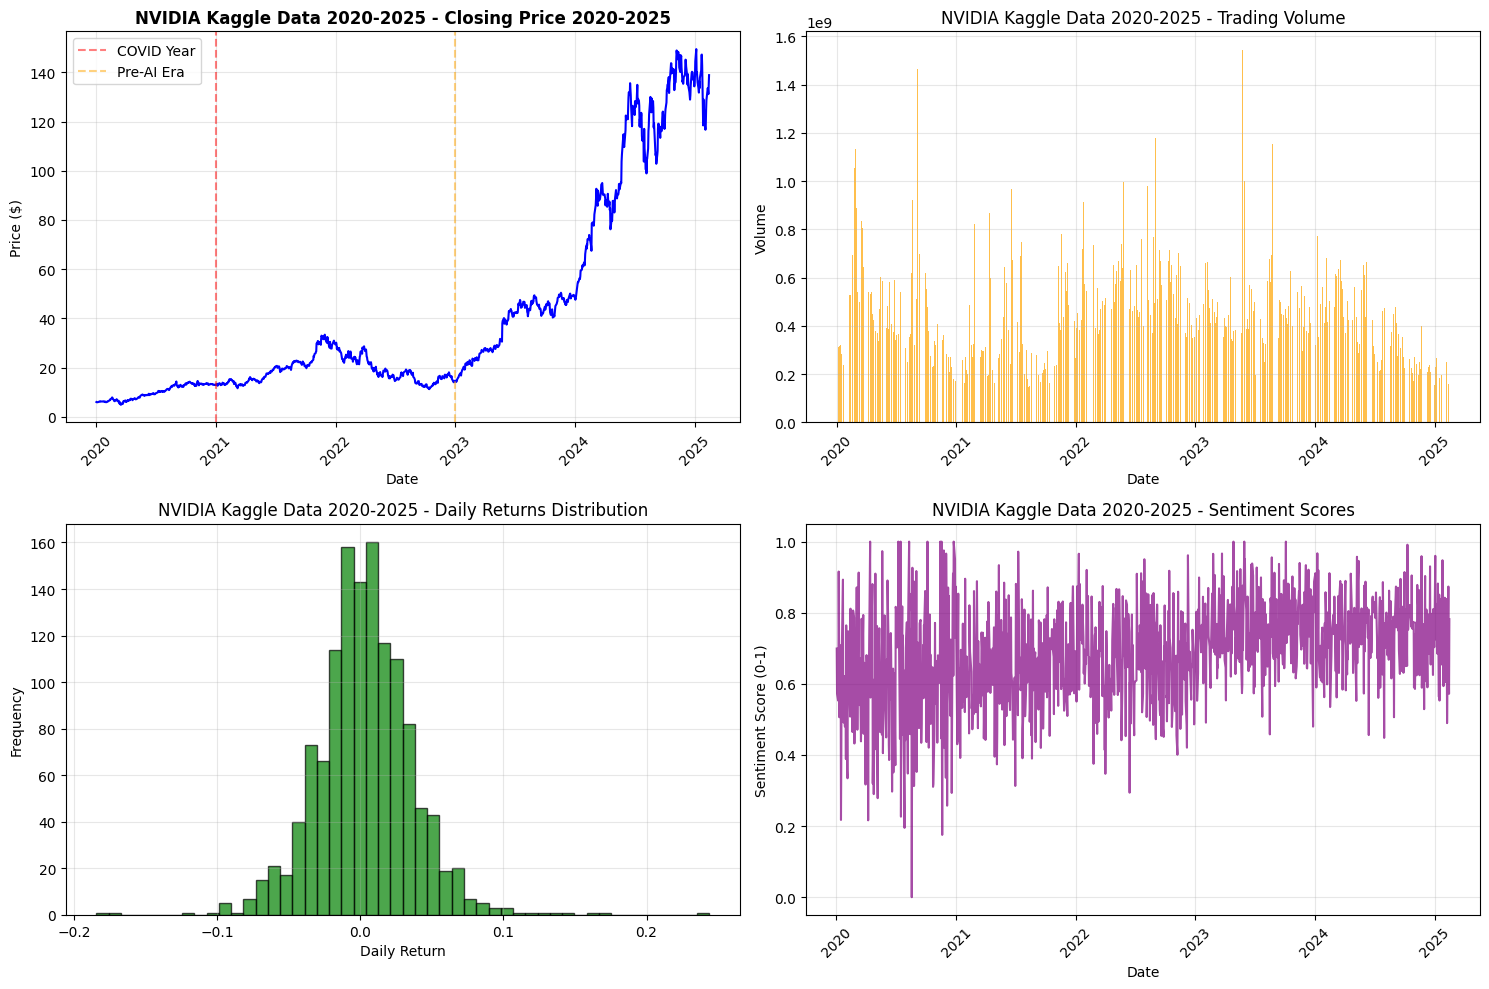

✅ Visualization saved: /content/drive/MyDrive/nvidia_stock_project_2020_2025/output/nvidia_kaggle_data_2020-2025_2020_2025.png


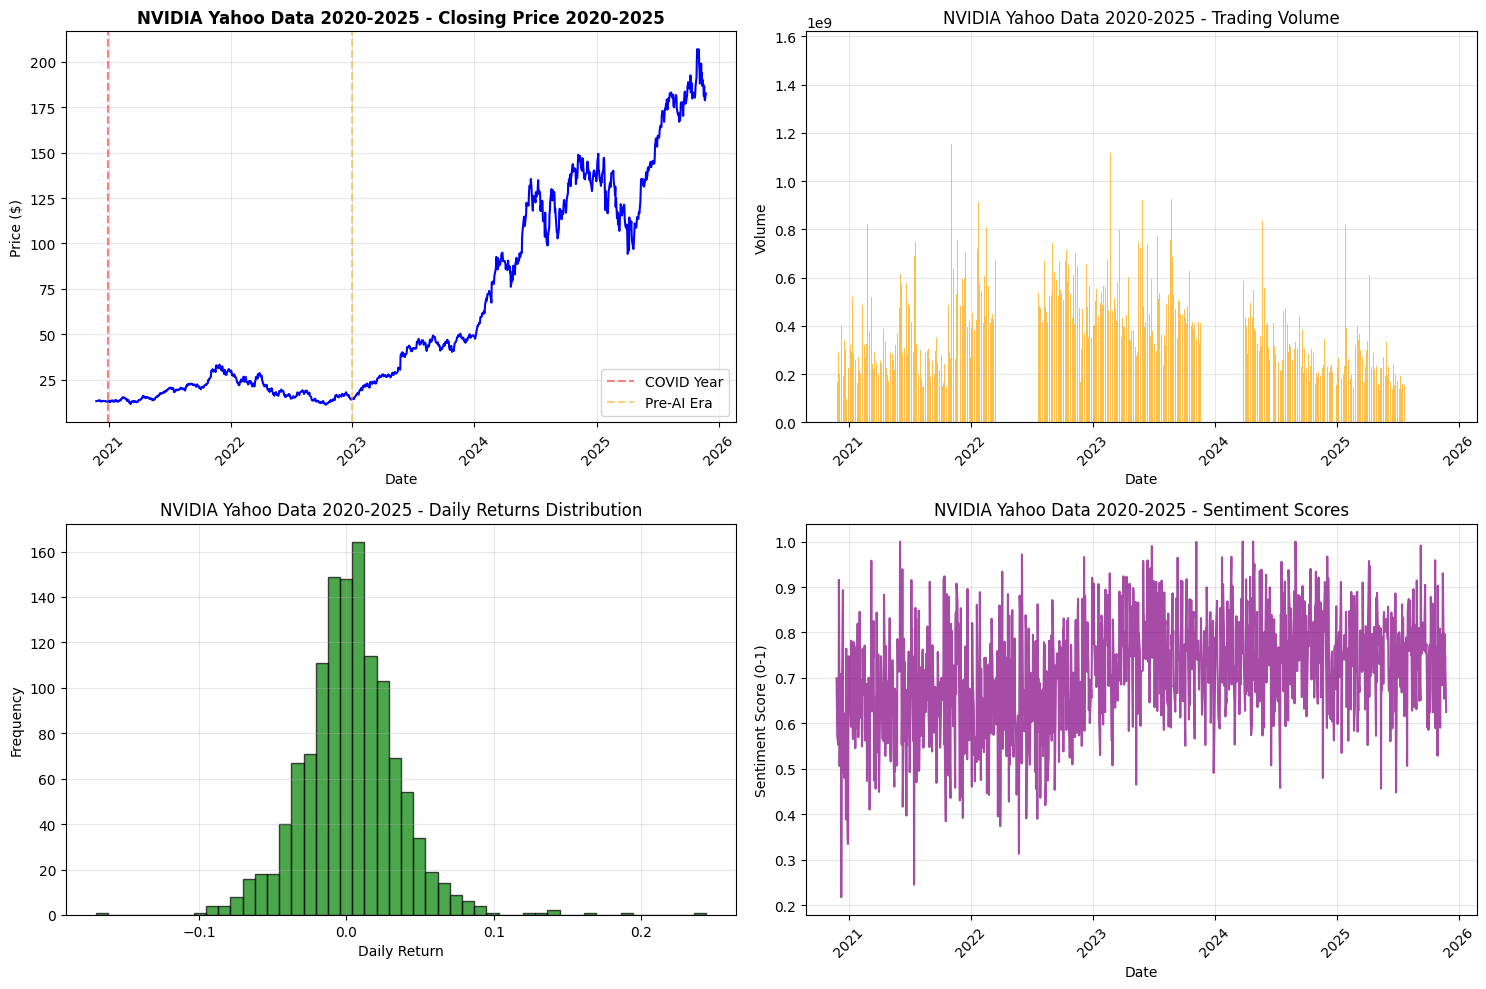

✅ Visualization saved: /content/drive/MyDrive/nvidia_stock_project_2020_2025/output/nvidia_yahoo_data_2020-2025_2020_2025.png


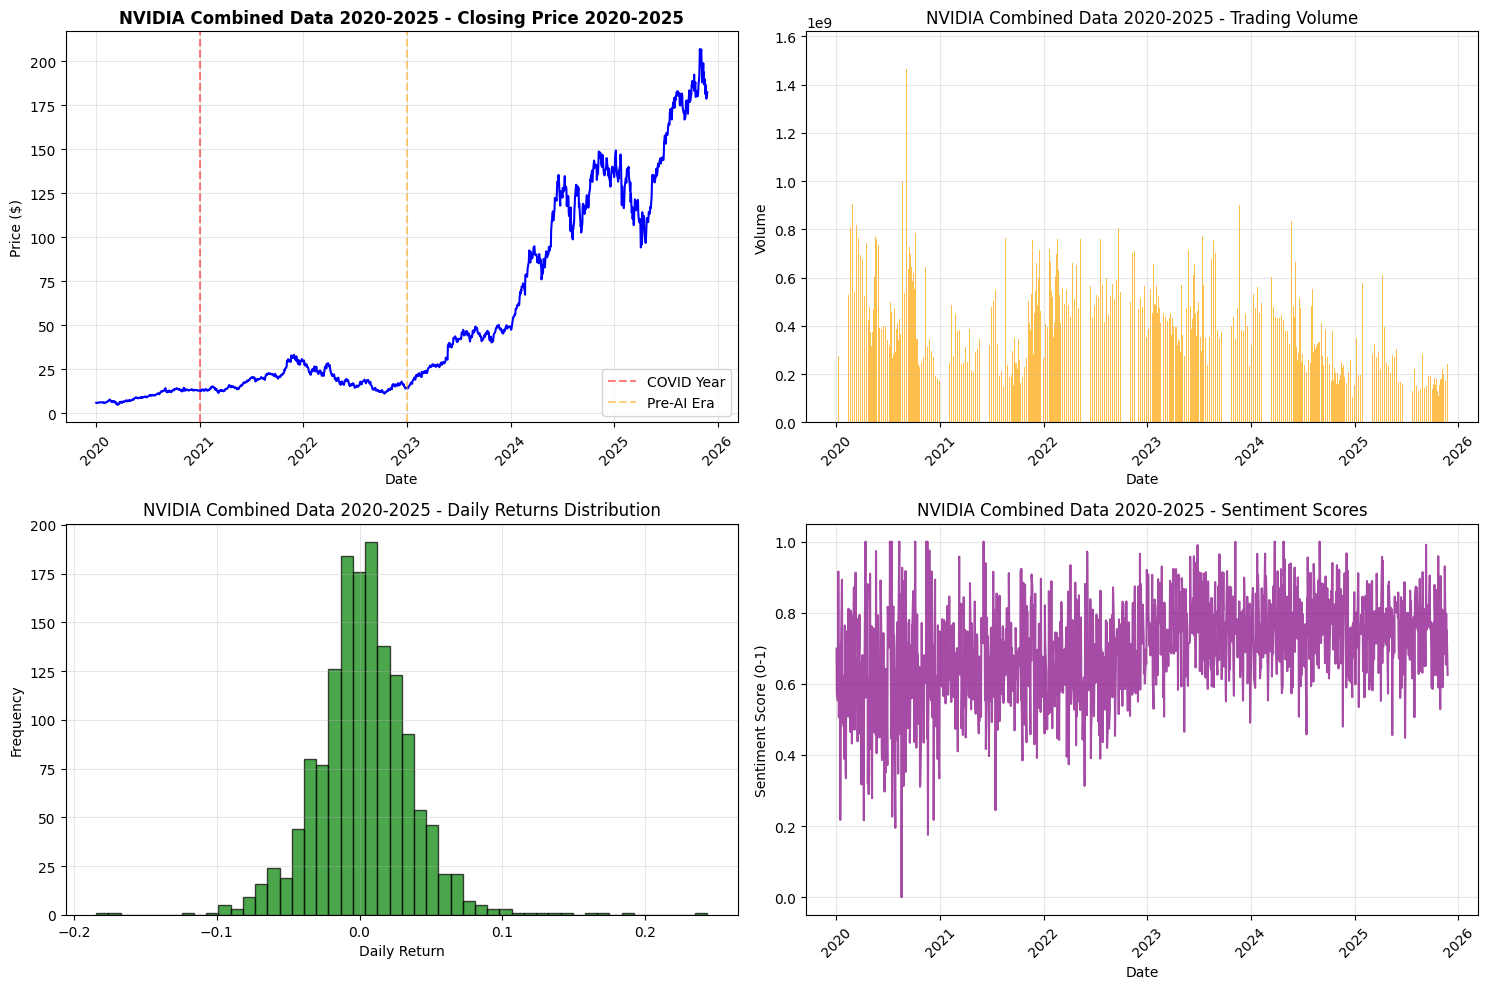

✅ Visualization saved: /content/drive/MyDrive/nvidia_stock_project_2020_2025/output/nvidia_combined_data_2020-2025_2020_2025.png

🎉==================================================
🎉 PIPELINE COMPLETED SUCCESSFULLY! 🎉

📊 FINAL RESULTS SUMMARY (2020-2025):
📍 Project folder: /content/drive/MyDrive/nvidia_stock_project_2020_2025
📍 Output directory: /content/drive/MyDrive/nvidia_stock_project_2020_2025/output
✅ Kaggle dataset: (1288, 27) records
✅ Yahoo dataset: (1255, 26) records
✅ Combined dataset: (1483, 27) records

📅 Data Period: 2020-2025
✨ Features: Technical indicators + Period-specific sentiment
💾 Storage: All files saved permanently in Google Drive

🚀 Your 2020-2025 NVIDIA data is ready for analysis!
📈 Perfect for modern ML models and trend analysis!


In [ ]:
# CREATE BASIC VISUALIZATIONS - IMPROVED VERSION
# ==================================================

def create_basic_visualizations_2020_2025(data, title):
    """Create basic charts to understand the 2020-2025 data"""

    if data.empty:
        print(f"⚠️ No data available for visualization: {title}")
        return

    if 'Date' not in data.columns or 'Close' not in data.columns:
        print(f"⚠️ Required columns missing for visualization: {title}")
        return

    plt.figure(figsize=(15, 10))

    # 1. Price chart with 2020-2025 context
    plt.subplot(2, 2, 1)
    plt.plot(data['Date'], data['Close'], linewidth=1.5, color='blue')
    plt.title(f'{title} - Closing Price 2020-2025', fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    # Add period annotations
    plt.axvline(pd.Timestamp('2020-12-31'), color='red', linestyle='--', alpha=0.5, label='COVID Year')
    plt.axvline(pd.Timestamp('2022-12-31'), color='orange', linestyle='--', alpha=0.5, label='Pre-AI Era')
    plt.legend()

    # 2. Volume chart (if available)
    if 'Volume' in data.columns:
        plt.subplot(2, 2, 2)
        plt.bar(data['Date'], data['Volume'], alpha=0.7, color='orange')
        plt.title(f'{title} - Trading Volume')
        plt.xlabel('Date')
        plt.ylabel('Volume')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)

    # 3. Returns distribution (if available)
    if 'daily_return' in data.columns:
        plt.subplot(2, 2, 3)
        returns = data['daily_return'].dropna()
        plt.hist(returns, bins=50, alpha=0.7, color='green', edgecolor='black')
        plt.title(f'{title} - Daily Returns Distribution')
        plt.xlabel('Daily Return')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)

    # 4. Sentiment scores (if available)
    if 'sentiment_score' in data.columns:
        plt.subplot(2, 2, 4)
        plt.plot(data['Date'], data['sentiment_score'], color='purple', alpha=0.7)
        plt.title(f'{title} - Sentiment Scores')
        plt.xlabel('Date')
        plt.ylabel('Sentiment Score (0-1)')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save the visualization
    viz_filename = f"{title.lower().replace(' ', '_')}_2020_2025.png"
    viz_path = f'{output_directory}/{viz_filename}'
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Visualization saved: {viz_path}")

print("\n" + "="*50)
print("CREATING VISUALIZATIONS")
print("="*50)

# Create visualizations for available datasets
if not kaggle_final.empty:
    create_basic_visualizations_2020_2025(kaggle_final, "NVIDIA Kaggle Data 2020-2025")

if not yahoo_final.empty:
    create_basic_visualizations_2020_2025(yahoo_final, "NVIDIA Yahoo Data 2020-2025")

if not combined_data.empty:
    create_basic_visualizations_2020_2025(combined_data, "NVIDIA Combined Data 2020-2025")

# FINAL SUMMARY
# ==================================================

print("\n🎉" + "="*50)
print("🎉 PIPELINE COMPLETED SUCCESSFULLY! 🎉")
print("="*50)

print("\n📊 FINAL RESULTS SUMMARY (2020-2025):")
print(f"📍 Project folder: /content/drive/MyDrive/nvidia_stock_project_2020_2025")
print(f"📍 Output directory: {output_directory}")

if not kaggle_final.empty:
    print(f"✅ Kaggle dataset: {kaggle_final.shape} records")
if not yahoo_final.empty:
    print(f"✅ Yahoo dataset: {yahoo_final.shape} records")
if not combined_data.empty:
    print(f"✅ Combined dataset: {combined_data.shape} records")

print(f"\n📅 Data Period: 2020-2025")
print("✨ Features: Technical indicators + Period-specific sentiment")
print("💾 Storage: All files saved permanently in Google Drive")

print("\n🚀 Your 2020-2025 NVIDIA data is ready for analysis!")
print("📈 Perfect for modern ML models and trend analysis!")

## News Sentiment


Install required libraries

In [ ]:
# Install required libraries
!pip install transformers torch newsapi-python gnews beautifulsoup4 requests

# Import libraries
from datetime import datetime, timedelta
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 6.3 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=b9153987379ffa1406a30398c4784cae8859776611e3cf93ff9708c8f92fc18a
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k


Load ProsusAI/FinBERT, a sentiment model trained on financial texts (e.g., market news, analyst reports). Its finance-specific training makes it more accurate than general models for detecting positive, neutral, or negative sentiment in stock-related news.

In [ ]:
# Initialize sentiment analysis model (using free HuggingFace model)
print("Loading sentiment analysis model...")
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",  # Financial domain-specific BERT model
    device=-1  # Use CPU, set to 0 for GPU
)

Loading sentiment analysis model...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


Fetch historical news articles from NewsAPI as an alternative to RSS feeds, offering better coverage and more metadata.

In [ ]:
# Alternative - Fetch news using NewsAPI (more historical data)
def fetch_news_newsapi(ticker, company_name, start_date, end_date, api_key=None):
    """
    Alternative method using NewsAPI for more comprehensive news coverage
    Requires free API key from https://newsapi.org/
    """
    if api_key is None:
        print("Note: To use NewsAPI, get free API key from https://newsapi.org/")
        return pd.DataFrame()

    from newsapi import NewsApiClient

    newsapi = NewsApiClient(api_key=api_key)

    # Convert dates
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    all_news = []

    # NewsAPI allows queries up to 1 month at a time for free tier
    current_date = start
    while current_date < end:
        next_date = min(current_date + timedelta(days=30), end)

        # Search for company-related news
        articles = newsapi.get_everything(
            q=f'{company_name} OR {ticker}',
            from_param=current_date.strftime('%Y-%m-%d'),
            to=next_date.strftime('%Y-%m-%d'),
            language='en',
            sort_by='relevancy',
            page_size=100
        )

        for article in articles['articles']:
            all_news.append({
                'date': pd.to_datetime(article['publishedAt']).date(),
                'title': article['title'],
                'description': article.get('description', ''),
                'publisher': article['source']['name']
            })

        current_date = next_date

    return pd.DataFrame(all_news)

Extract news articles from Google News

In [ ]:
# Google News scraper
def fetch_google_news(query, start_date, end_date):
    """
    Fetch news from Google News using gnews library
    No API key required!
    """
    from gnews import GNews

    print(f"Fetching Google News for: {query}")

    # Initialize GNews
    google_news = GNews(
        language='en',
        country='US',
        period=None,  # We'll filter by date manually
        max_results=100
    )

    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)

    all_news = []

    try:
        # Fetch news for different time periods
        # Split into yearly chunks to get more coverage
        current_date = start

        while current_date < end:
            next_date = min(current_date + timedelta(days=365), end)

            # Set date range
            google_news.start_date = (current_date.year, current_date.month, current_date.day)
            google_news.end_date = (next_date.year, next_date.month, next_date.day)

            # Search for news
            news_items = google_news.get_news(query)

            for article in news_items:
                try:
                    pub_date = pd.to_datetime(article['published date']).date()
                    all_news.append({
                        'date': pub_date,
                        'title': article['title'],
                        'publisher': article.get('publisher', {}).get('title', 'Unknown'),
                        'description': article.get('description', ''),
                        'url': article.get('url', '')
                    })
                except:
                    continue

            current_date = next_date
            print(f"Fetched {len(news_items)} articles up to {next_date.date()}")

        if all_news:
            news_df = pd.DataFrame(all_news)
            print(f"Total articles found: {len(news_df)}")
            return news_df
        else:
            print("No news articles found.")
            return pd.DataFrame()

    except Exception as e:
        print(f"Error fetching Google News: {e}")
        return pd.DataFrame()

Convert financial text into a clean numerical sentiment score using the FinBERT model.
This function classifies each headline/article as positive (1), neutral (0), or negative (-1) while applying confidence-based thresholds to reduce noise from ambiguous or low-certainty predictions.
The strict option increases neutrality for borderline cases, improving reliability of sentiment inputs used for forecasting.

In [ ]:
# Sentiment classification function
def classify_sentiment(text, strict=False):
    """
    Classify sentiment using FinBERT model
    Returns: -1 (negative), 0 (neutral), 1 (positive)

    Args:
        text: Text to classify
        strict: If True, uses higher thresholds (more neutral classifications)
                If False, uses lower thresholds (more definitive classifications)
    """
    if pd.isna(text) or text == '':
        return 0

    try:
        # Truncate text to avoid token limit
        text = text[:512]

        result = sentiment_analyzer(text)[0]
        label = result['label'].lower()
        score = result['score']

        # FinBERT outputs: positive, negative, neutral
        # Adjust thresholds based on strict parameter
        confidence_threshold = 0.70 if strict else 0.55

        if score > confidence_threshold:
            if 'positive' in label:
                return 1
            elif 'negative' in label:
                return -1
            elif 'neutral' in label:
                return 0

        # If confidence is moderate (between thresholds), still assign sentiment
        if not strict and score > 0.45:
            if 'positive' in label:
                return 1
            elif 'negative' in label:
                return -1

        return 0
    except Exception as e:
        print(f"Error in sentiment analysis: {e}")
        return 0

Convert individual news article sentiments into consolidated daily sentiment metrics for time series analysis.

In [ ]:
# Aggregate daily sentiment
def aggregate_daily_sentiment(news_df, aggregation_method='weighted'):
    """
    Aggregate multiple news articles per day into single sentiment score

    Args:
        aggregation_method:
            - 'weighted': Considers strength of sentiment (recommended)
            - 'majority': Simple majority vote
            - 'average': Simple average
    """
    if news_df.empty:
        return pd.DataFrame()

    # Classify sentiment for each article
    print("\nClassifying sentiment for each article...")
    print("This may take a few minutes depending on the number of articles...")

    # Use title and description if available
    news_df['text_to_analyze'] = news_df.apply(
        lambda row: f"{row['title']} {row.get('description', '')}", axis=1
    )

    # Get both sentiment classification and raw scores
    sentiments = []
    raw_scores = []

    for text in news_df['text_to_analyze']:
        if pd.isna(text) or text == '':
            sentiments.append(0)
            raw_scores.append(0)
            continue

        try:
            text = text[:512]
            result = sentiment_analyzer(text)[0]
            label = result['label'].lower()
            score = result['score']

            # Store raw sentiment score (-1 to 1)
            if 'positive' in label:
                raw_scores.append(score)
                sentiments.append(1 if score > 0.55 else 0)
            elif 'negative' in label:
                raw_scores.append(-score)
                sentiments.append(-1 if score > 0.55 else 0)
            else:
                raw_scores.append(0)
                sentiments.append(0)
        except:
            sentiments.append(0)
            raw_scores.append(0)

    news_df['sentiment'] = sentiments
    news_df['raw_sentiment_score'] = raw_scores

    print(f"Sentiment classification complete!")
    print(f"Positive: {(news_df['sentiment'] == 1).sum()}")
    print(f"Neutral: {(news_df['sentiment'] == 0).sum()}")
    print(f"Negative: {(news_df['sentiment'] == -1).sum()}")

    # Aggregate by date based on method
    if aggregation_method == 'weighted':
        # Weight by confidence scores
        daily_sentiment = news_df.groupby('date').agg({
            'raw_sentiment_score': 'mean',  # Average of weighted scores
            'sentiment': 'count',
            'title': lambda x: ' | '.join(x[:3])
        }).reset_index()
        daily_sentiment.columns = ['date', 'sentiment_score', 'news_count', 'headlines']

    elif aggregation_method == 'majority':
        # Simple majority vote
        daily_sentiment = news_df.groupby('date').agg({
            'sentiment': lambda x: x.mode()[0] if len(x.mode()) > 0 else 0,
            'sentiment': 'count',
            'title': lambda x: ' | '.join(x[:3])
        }).reset_index()
        daily_sentiment.columns = ['date', 'sentiment_score', 'news_count', 'headlines']

    else:  # average
        daily_sentiment = news_df.groupby('date').agg({
            'sentiment': 'mean',
            'sentiment': 'count',
            'title': lambda x: ' | '.join(x[:3])
        }).reset_index()
        daily_sentiment.columns = ['date', 'sentiment_score', 'news_count', 'headlines']

    # Convert sentiment score to -1, 0, 1 with more sensitive thresholds
    # Using ±0.15 instead of ±0.2 for more definitive classifications
    daily_sentiment['sentiment_flag'] = daily_sentiment['sentiment_score'].apply(
        lambda x: 1 if x > 0.15 else (-1 if x < -0.15 else 0)
    )

    return daily_sentiment

Merge stock price data with aggregated news sentiment to create a unified dataset for machine learning.

In [ ]:
def integrate_news_sentiment(stock_df, ticker='NVDA', company_name='nvidia semiconductor', news_api_key=None):
    """
    Main function to integrate news sentiment into stock data
    Uses Google News for historical data (2020-2025)
    """
    # Ensure date column is datetime
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])

    start_date = stock_df['Date'].min()
    end_date = stock_df['Date'].max()

    print(f"Processing date range: {start_date.date()} to {end_date.date()}")
    print("="*60)

    all_news = []
    source_counts = {}

    # Method 1: Google News (Primary source for historical data)
    print("\n[Method 1] Fetching from Google News...")
    try:
        gnews_df = fetch_google_news(f'{company_name} OR {ticker}', start_date, end_date)
        if not gnews_df.empty:
            gnews_df['source'] = 'Google News'
            all_news.append(gnews_df)
            source_counts['Google News'] = len(gnews_df)
            print(f"\u2713 Fetched {len(gnews_df)} articles from Google News")
        else:
            print(f"\u26A0 No articles from Google News")
    except Exception as e:
        print(f"\u2718 Google News failed: {e}")

    # Method 2: NewsAPI (Optional - if API key provided)
    if news_api_key:
        print("\n[Method 2] Fetching from NewsAPI...")
        try:
            newsapi_data = fetch_news_newsapi(ticker, company_name, start_date, end_date, news_api_key)
            if not newsapi_data.empty:
                newsapi_data['source'] = 'NewsAPI'
                all_news.append(newsapi_data)
                source_counts['NewsAPI'] = len(newsapi_data)
                print(f"\u2713 Fetched {len(newsapi_data)} articles from NewsAPI")
            else:
                print(f"\u26A0 No articles from NewsAPI")
        except Exception as e:
            print(f"\u2718 NewsAPI failed: {e}")

    print("="*60)

    # Combine all news sources
    if not all_news:
        print("\n\u26A0 WARNING: No news found.")
        print("Creating dataset with default sentiment values (0).")
        stock_df['news_sentiment_flag_raw'] = 0
        stock_df['news_article_count'] = 0
        stock_df['news_sentiment_score_raw'] = 0.0
        return stock_df

    # Concatenate all news dataframes
    news_df = pd.concat(all_news, ignore_index=True)
    print(f"\n\U0001f4f0 Total articles: {len(news_df)}")

    # Show breakdown by source
    print("\n\U0001f4ca Articles by source:")
    for source, count in source_counts.items():
        print(f"   {source}: {count} articles ({count/len(news_df)*100:.1f}%)")

    # Remove duplicates
    before_dedup = len(news_df)
    news_df = news_df.drop_duplicates(subset=['date', 'title'], keep='first')
    after_dedup = len(news_df)

    if before_dedup - after_dedup > 0:
        print(f"\n\U0001f504 Duplicates removed: {before_dedup - after_dedup}")
    print(f"\u2705 Unique articles: {after_dedup}")

    # Aggregate daily sentiment
    daily_sentiment = aggregate_daily_sentiment(news_df)

    # Debugging: Print daily_sentiment before merge
    print("\n--- Debug: daily_sentiment before merge ---")
    print(daily_sentiment.head())
    print(daily_sentiment.info())

    # RENAME SENTIMENT COLUMNS IN daily_sentiment TO AVOID CONFLICTS
    daily_sentiment = daily_sentiment.rename(columns={
        'sentiment_flag': 'news_sentiment_flag_raw',
        'news_count': 'news_article_count',
        'sentiment_score': 'news_sentiment_score_raw'
    })

    # Merge with stock data
    stock_df['date'] = stock_df['Date'].dt.date

    # Debugging: Check date overlap
    stock_dates = set(stock_df['date'].unique())
    sentiment_dates = set(daily_sentiment['date'].unique())
    overlap_dates = stock_dates.intersection(sentiment_dates)

    print(f"\n--- Debug: Date Overlap ---")
    print(f"Stock DataFrame unique dates: {len(stock_dates)}")
    print(f"Daily Sentiment unique dates: {len(sentiment_dates)}")
    print(f"Overlapping dates: {len(overlap_dates)}")
    if len(overlap_dates) == 0:
        print("\u274c CRITICAL: No overlapping dates between stock data and daily sentiment.")
    else:
        print("\u2705 Overlapping dates found.")

    merged_df = stock_df.merge(
        daily_sentiment[['date', 'news_sentiment_flag_raw', 'news_article_count', 'news_sentiment_score_raw']],
        on='date',
        how='left'
    )

    # Fill missing values for the newly merged news sentiment columns
    merged_df['news_sentiment_flag_raw'] = merged_df['news_sentiment_flag_raw'].fillna(0).astype(int)
    merged_df['news_article_count'] = merged_df['news_article_count'].fillna(0).astype(int)
    merged_df['news_sentiment_score_raw'] = merged_df['news_sentiment_score_raw'].fillna(0.0)

    # Drop temporary column
    merged_df = merged_df.drop('date', axis=1)

    return merged_df

Create a robust sentiment feature that captures both daily news events and long-term market trends for more accurate forecasting.

In [ ]:
# Execute the pipeline - BLENDED SENTIMENT APPROACH
# ========================================================================
# This version blends real news sentiment with time-period sentiment
# to capture both daily news events AND major era trends
# ========================================================================

# Load your filtered data
csv_path = '/content/drive/MyDrive/nvidia_stock_project_2020_2025/output/nvidia_2020_2025_combined_normalized.csv'
df = pd.read_csv(csv_path)

print("Starting news sentiment integration pipeline...")
print("This will fetch news from Google News and classify sentiment.\n")

# Run sentiment integration
df_with_sentiment = integrate_news_sentiment(
    df,
    ticker='NVDA',
    company_name='nvidia semiconductor',
    news_api_key=None
)

# --- SIMPLIFIED COLUMN HANDLING ---
# The integrate_news_sentiment function already creates the correct columns:
# - news_sentiment_flag_raw
# - news_article_count
# - news_sentiment_score_raw

# Check what columns we actually have
print("\n--- Debug: Columns after integrate_news_sentiment ---")
print([col for col in df_with_sentiment.columns if 'sentiment' in col.lower() or 'news' in col.lower()])

# Only handle columns that might conflict with existing ones
# If there's a sentiment_score column from the original CSV, preserve it
if 'sentiment_score' in df_with_sentiment.columns and 'news_sentiment_score_raw' not in df_with_sentiment.columns:
    # Old CSV format - sentiment_score exists but news columns don't
    df_with_sentiment['original_mock_sentiment_score'] = df_with_sentiment['sentiment_score']
    df_with_sentiment = df_with_sentiment.drop(columns=['sentiment_score'])

# Ensure the news columns exist (they should from integrate_news_sentiment)
if 'news_sentiment_score_raw' not in df_with_sentiment.columns:
    df_with_sentiment['news_sentiment_score_raw'] = 0.0
if 'news_sentiment_flag_raw' not in df_with_sentiment.columns:
    df_with_sentiment['news_sentiment_flag_raw'] = 0
if 'news_article_count' not in df_with_sentiment.columns:
    df_with_sentiment['news_article_count'] = 0

# Fill NaNs only (don't overwrite existing values)
df_with_sentiment['news_sentiment_score_raw'] = df_with_sentiment['news_sentiment_score_raw'].fillna(0.0)
df_with_sentiment['news_sentiment_flag_raw'] = df_with_sentiment['news_sentiment_flag_raw'].fillna(0).astype(int)
df_with_sentiment['news_article_count'] = df_with_sentiment['news_article_count'].fillna(0).astype(int)

print("✓ Columns verified and adjusted for blending.")

# Verify news article count
print(f"\n--- News Article Count Verification ---")
print(f"Total rows: {len(df_with_sentiment)}")
print(f"Rows with news (count > 0): {(df_with_sentiment['news_article_count'] > 0).sum()}")
print(f"Total news articles: {df_with_sentiment['news_article_count'].sum()}")
print(f"Max articles in a day: {df_with_sentiment['news_article_count'].max()}")

# Show sample of days with news
if (df_with_sentiment['news_article_count'] > 0).any():
    print("\nSample of days with news:")
    print(df_with_sentiment[df_with_sentiment['news_article_count'] > 0][['Date', 'news_article_count', 'news_sentiment_score_raw']].head(10))
else:
    print("\n⚠️ WARNING: No news articles found in any day!")
# ---------------------------------------------------

# ========================================================================
# CREATE TIME-PERIOD SENTIMENT (Historical Context)
# ========================================================================
print("\n" + "="*60)
print("CREATING TIME-PERIOD SENTIMENT FEATURES")
print("="*60)

def calculate_time_period_sentiment(date):
    """
    Calculate sentiment based on historical periods and major events
    This captures macro trends beyond daily news

    Returns: (polarity, subjectivity, score, period_name)
    """
    year = pd.to_datetime(date).year
    month = pd.to_datetime(date).month

    # COVID-2020 Era: High volatility, initially negative then recovery
    if year == 2020:
        if month <= 3:  # Pre-COVID crash
            return (0.1, 0.6, 0.55, 'pre_covid_2020')
        elif month <= 6:  # COVID crash and recovery
            return (-0.3, 0.8, 0.35, 'covid_crash_2020')
        else:  # Work-from-home boom
            return (0.4, 0.7, 0.70, 'wfh_boom_2020')

    # Transition Era 2021-2022: Mixed sentiment
    elif year == 2021:
        return (0.3, 0.6, 0.65, 'recovery_2021')
    elif year == 2022:
        if month <= 6:
            return (0.2, 0.6, 0.60, 'early_2022')
        else:  # Crypto winter, tech downturn
            return (-0.1, 0.7, 0.45, 'tech_downturn_2022')

    # AI Boom Era 2023+: Very positive for NVIDIA
    elif year == 2023:
        if month <= 5:
            return (0.5, 0.6, 0.75, 'ai_emergence_2023')
        else:  # ChatGPT boom, GPU shortage
            return (0.7, 0.7, 0.85, 'ai_boom_2023')
    elif year >= 2024:
        return (0.6, 0.65, 0.80, 'ai_dominance_2024+')

    return (0.0, 0.5, 0.5, 'unknown')

# Apply time-period sentiment
print("Calculating time-period sentiment for each date...")
time_period_data = df_with_sentiment['Date'].apply(
    lambda d: pd.Series(calculate_time_period_sentiment(d))
)
time_period_data.columns = ['time_polarity', 'time_subjectivity', 'time_score', 'time_period_name']

df_with_sentiment = pd.concat([df_with_sentiment, time_period_data], axis=1)

# Replace the original 'sentiment_period' with the newly calculated one
df_with_sentiment['sentiment_period'] = df_with_sentiment['time_period_name']
df_with_sentiment = df_with_sentiment.drop(columns=['time_period_name'], errors='ignore')

print("✅ Time-period sentiment created!")
print(f"\nPeriods identified:")
for period in df_with_sentiment['sentiment_period'].unique():
    count = (df_with_sentiment['sentiment_period'] == period).sum()
    avg_score = df_with_sentiment[df_with_sentiment['sentiment_period'] == period]['time_score'].mean()
    print(f"  {period}: {count} days (avg score: {avg_score:.3f})")

# ========================================================================
# BLEND NEWS SENTIMENT WITH TIME-PERIOD SENTIMENT
# ========================================================================
print("\n" + "="*60)
print("BLENDING NEWS SENTIMENT + TIME-PERIOD SENTIMENT")
print("="*60)

# Strategy:
# - For days WITH news: 70% news sentiment + 30% time-period sentiment
# - For days WITHOUT news: 100% time-period sentiment

def blend_sentiments(row, news_weight=0.7, time_weight=0.3):
    """
    Blend real news sentiment with time-period sentiment

    Args:
        news_weight: Weight for real news (0-1), default 0.7
        time_weight: Weight for time period (0-1), default 0.3
    """
    if row['news_article_count'] > 0:
        # Has news: blend both
        blended_polarity = (row['news_sentiment_score_raw'] * news_weight +
                           row['time_polarity'] * time_weight)
        blended_score = ((row['news_sentiment_score_raw'] + 1) / 2 * news_weight +
                        row['time_score'] * time_weight)
        blended_subjectivity = (row['news_article_count'] * 0.05 * news_weight +
                               row['time_subjectivity'] * time_weight)
        blended_flag = 1 if blended_polarity > 0.2 else (-1 if blended_polarity < -0.2 else 0)
    else:
        # No news: use time-period sentiment only
        blended_polarity = row['time_polarity']
        blended_score = row['time_score']
        blended_subjectivity = row['time_subjectivity']
        blended_flag = 1 if blended_polarity > 0.2 else (-1 if blended_polarity < -0.2 else 0)

    return pd.Series({
        'blended_sentiment_polarity': blended_polarity,
        'blended_sentiment_score': blended_score,
        'blended_sentiment_subjectivity': min(blended_subjectivity, 0.9),
        'final_sentiment_flag': blended_flag
    })

# Apply blending
print("Blending sentiments (70% news + 30% time-period)...")
blended_results = df_with_sentiment.apply(blend_sentiments, axis=1)

# Assign the blended sentiment results to new columns in the main DataFrame
df_with_sentiment['blended_sentiment_polarity'] = blended_results['blended_sentiment_polarity']
df_with_sentiment['blended_sentiment_subjectivity'] = blended_results['blended_sentiment_subjectivity']
df_with_sentiment['blended_sentiment_score'] = blended_results['blended_sentiment_score']
df_with_sentiment['final_sentiment_flag'] = blended_results['final_sentiment_flag']

print("✅ Sentiment blending complete!")

# Add data source indicator
df_with_sentiment['data_source_blended'] = df_with_sentiment.apply(
    lambda row: 'news+time' if row['news_article_count'] > 0 else 'time_only',
    axis=1
)

# ========================================================================
# DISPLAY RESULTS
# ========================================================================
print("\n" + "="*60)
print("BLENDED SENTIMENT RESULTS")
print("="*60)

# Reorder columns for display
column_order = [
    'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
    'final_sentiment_flag', 'news_article_count',
    'blended_sentiment_polarity', 'blended_sentiment_subjectivity', 'blended_sentiment_score',
    'sentiment_period', 'data_source_blended',
    'news_sentiment_score_raw', 'news_sentiment_flag_raw',
    'time_polarity', 'time_subjectivity', 'time_score',
    'original_mock_sentiment_score'
]

existing_columns = [col for col in column_order if col in df_with_sentiment.columns]
df_with_sentiment = df_with_sentiment[existing_columns]

display(df_with_sentiment.head(20))

print(f"\nDataset shape: {df_with_sentiment.shape}")

# Show blended results
print(f"\n📊 Final Sentiment Flag Distribution (blended):")
sentiment_dist = df_with_sentiment['final_sentiment_flag'].value_counts().sort_index()
for sent, count in sentiment_dist.items():
    label = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}[sent]
    print(f"  {label}: {count} days ({count/len(df_with_sentiment)*100:.1f}%)")

print(f"\n📰 Data Source Breakdown (blended sentiment):")
source_dist = df_with_sentiment['data_source_blended'].value_counts()
for source, count in source_dist.items():
    print(f"  {source}: {count} days ({count/len(df_with_sentiment)*100:.1f}%)")

Starting news sentiment integration pipeline...
This will fetch news from Google News and classify sentiment.

Processing date range: 2020-01-02 to 2025-11-24

[Method 1] Fetching from Google News...
Fetching Google News for: nvidia semiconductor OR NVDA
Fetched 56 articles up to 2021-01-01
Fetched 85 articles up to 2022-01-01
Fetched 100 articles up to 2023-01-01
Fetched 100 articles up to 2024-01-01
Fetched 100 articles up to 2024-12-31
Fetched 100 articles up to 2025-11-24
Total articles found: 541
✓ Fetched 541 articles from Google News

📰 Total articles: 541

📊 Articles by source:
   Google News: 541 articles (100.0%)
✅ Unique articles: 541

Classifying sentiment for each article...
This may take a few minutes depending on the number of articles...
Sentiment classification complete!
Positive: 61
Neutral: 408
Negative: 72

--- Debug: daily_sentiment before merge ---
         date  sentiment_score  news_count  \
0  2020-01-08              0.0           1   
1  2020-02-13            

,Date,Open,High,Low,Close,Volume,final_sentiment_flag,news_article_count,blended_sentiment_polarity,blended_sentiment_subjectivity,blended_sentiment_score,sentiment_period,data_source_blended,news_sentiment_score_raw,news_sentiment_flag_raw,time_polarity,time_subjectivity,time_score
0,2020-01-02,0.004758,0.003621,0.006969,0.005381,0.096576,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55
1,2020-01-03,0.004309,0.003369,0.006643,0.004906,0.074342,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55
2,2020-01-06,0.003966,0.003302,0.006291,0.005029,0.113934,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55
3,2020-01-07,0.004690,0.003845,0.006928,0.005384,0.150047,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55
4,2020-01-08,0.004882,0.003878,0.007146,0.005440,0.123942,0.0,1,0.03,0.215,0.515,pre_covid_2020,news+time,0.0,0,0.1,0.6,0.55
5,2020-01-09,0.005386,0.004348,0.007483,0.005766,0.108731,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55
6,2020-01-10,0.005814,0.004664,0.007843,0.005927,0.151043,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55
7,2020-01-13,0.005855,0.005201,0.008216,0.006874,0.153494,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55
8,2020-01-14,0.006175,0.004994,0.008216,0.006293,0.180636,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55
9,2020-01-15,0.005871,0.004681,0.007940,0.006081,0.114258,0.0,0,0.10,0.600,0.550,pre_covid_2020,time_only,0.0,0,0.1,0.6,0.55



Dataset shape: (1483, 18)

📊 Final Sentiment Flag Distribution (blended):
  Negative: 92 days (6.2%)
  Neutral: 440 days (29.7%)
  Positive: 951 days (64.1%)

📰 Data Source Breakdown (blended sentiment):
  time_only: 1172 days (79.0%)
  news+time: 311 days (21.0%)


Save the enriched dataset and provide detailed analytics on the blended sentiment methodology.

In [ ]:
# Save enriched dataset with blended sentiment
output_path = '/content/drive/MyDrive/nvidia_stock_project_2020_2025/output/NVDA_2020_2025_with_blended_sentiment.csv'
df_with_sentiment.to_csv(output_path, index=False)
print(f"\n💾 Blended sentiment dataset saved to: {output_path}")

# Cell 10b: Analyze blended sentiment distribution
print("\n" + "="*60)
print("BLENDED SENTIMENT ANALYSIS")
print("="*60)

total_days = len(df_with_sentiment)
days_with_news = (df_with_sentiment['news_article_count'] > 0).sum()
days_no_news = total_days - days_with_news

print(f"\n📊 Dataset Overview:")
print(f"  Total days: {total_days}")
print(f"  Days with news (news+time blend): {days_with_news} ({days_with_news/total_days*100:.1f}%)")
print(f"  Days without news (time-only): {days_no_news} ({days_no_news/total_days*100:.1f}%)")

# Analyze blended sentiment effectiveness
print(f"\n📈 Blended Sentiment Distribution:")
for sent in [-1, 0, 1]:
    count = (df_with_sentiment['final_sentiment_flag'] == sent).sum()
    pct = count / total_days * 100
    label = {-1: 'Negative \U0001f53d', 0: 'Neutral \u27a1\ufe0f', 1: 'Positive \U0001f4c8'}[sent]
    print(f"  {label}: {count} days ({pct:.1f}%)")

# Compare periods
print(f"\n\U0001f4c5 Sentiment by Historical Period:")
for period in sorted(df_with_sentiment['sentiment_period'].unique()):
    period_data = df_with_sentiment[df_with_sentiment['sentiment_period'] == period]
    avg_sentiment = period_data['blended_sentiment_polarity'].mean()
    avg_news = period_data['news_article_count'].mean()
    days = len(period_data)

    sentiment_emoji = "\U0001f4c8" if avg_sentiment > 0.3 else ("\U0001f53d" if avg_sentiment < -0.1 else "\u27a1\ufe0f")
    print(f"\n  {period} {sentiment_emoji}")
    print(f"    Days: {days}")
    print(f"    Avg polarity: {avg_sentiment:.3f}")
    print(f"    Avg news/day: {avg_news:.2f}")
    print(f"    Positive days: {(period_data['final_sentiment_flag'] == 1).sum()} ({(period_data['final_sentiment_flag'] == 1).sum()/days*100:.1f}%)")
    print(f"    Negative days: {(period_data['final_sentiment_flag'] == -1).sum()} ({(period_data['final_sentiment_flag'] == -1).sum()/days*100:.1f}%)")

print("\n" + "="*60)
print("\U0001f4a1 BLENDING BENEFITS:")
print("="*60)
print("""
\u2705 Days WITH news: Real news sentiment (70%) + Historical context (30%)
   \u2192 Captures both daily events AND macro trends

\u2705 Days WITHOUT news: Historical context (100%)
   \u2192 No gaps in sentiment data, always have context

\u2705 Historical periods provide:
   - COVID-2020: Captures pandemic impact on tech
   - Recovery-2021: Post-pandemic tech boom
   - Tech-Downturn-2022: Crypto winter, recession fears
   - AI-Boom-2023+: ChatGPT era, GPU shortage, NVIDIA dominance

This hybrid approach gives your ML model BOTH:
  1. Granular daily news sentiment (when available)
  2. Macro historical context (always present)
""")


💾 Blended sentiment dataset saved to: /content/drive/MyDrive/nvidia_stock_project_2020_2025/output/NVDA_2020_2025_with_blended_sentiment.csv

BLENDED SENTIMENT ANALYSIS

📊 Dataset Overview:
  Total days: 1483
  Days with news (news+time blend): 311 (21.0%)
  Days without news (time-only): 1172 (79.0%)

📈 Blended Sentiment Distribution:
  Negative 🔽: 92 days (6.2%)
  Neutral ➡️: 440 days (29.7%)
  Positive 📈: 951 days (64.1%)

📅 Sentiment by Historical Period:

  ai_boom_2023 📈
    Days: 147
    Avg polarity: 0.531
    Avg news/day: 0.51
    Positive days: 137 (93.2%)
    Negative days: 3 (2.0%)

  ai_dominance_2024+ 📈
    Days: 477
    Avg polarity: 0.507
    Avg news/day: 0.37
    Positive days: 398 (83.4%)
    Negative days: 13 (2.7%)

  ai_emergence_2023 📈
    Days: 103
    Avg polarity: 0.482
    Avg news/day: 0.17
    Positive days: 99 (96.1%)
    Negative days: 0 (0.0%)

  covid_crash_2020 🔽
    Days: 63
    Avg polarity: -0.251
    Avg news/day: 0.19
    Positive days: 2 (3.2%)

Generate insightful charts that demonstrate how the blended sentiment correlates with NVIDIA's stock price movements over time.

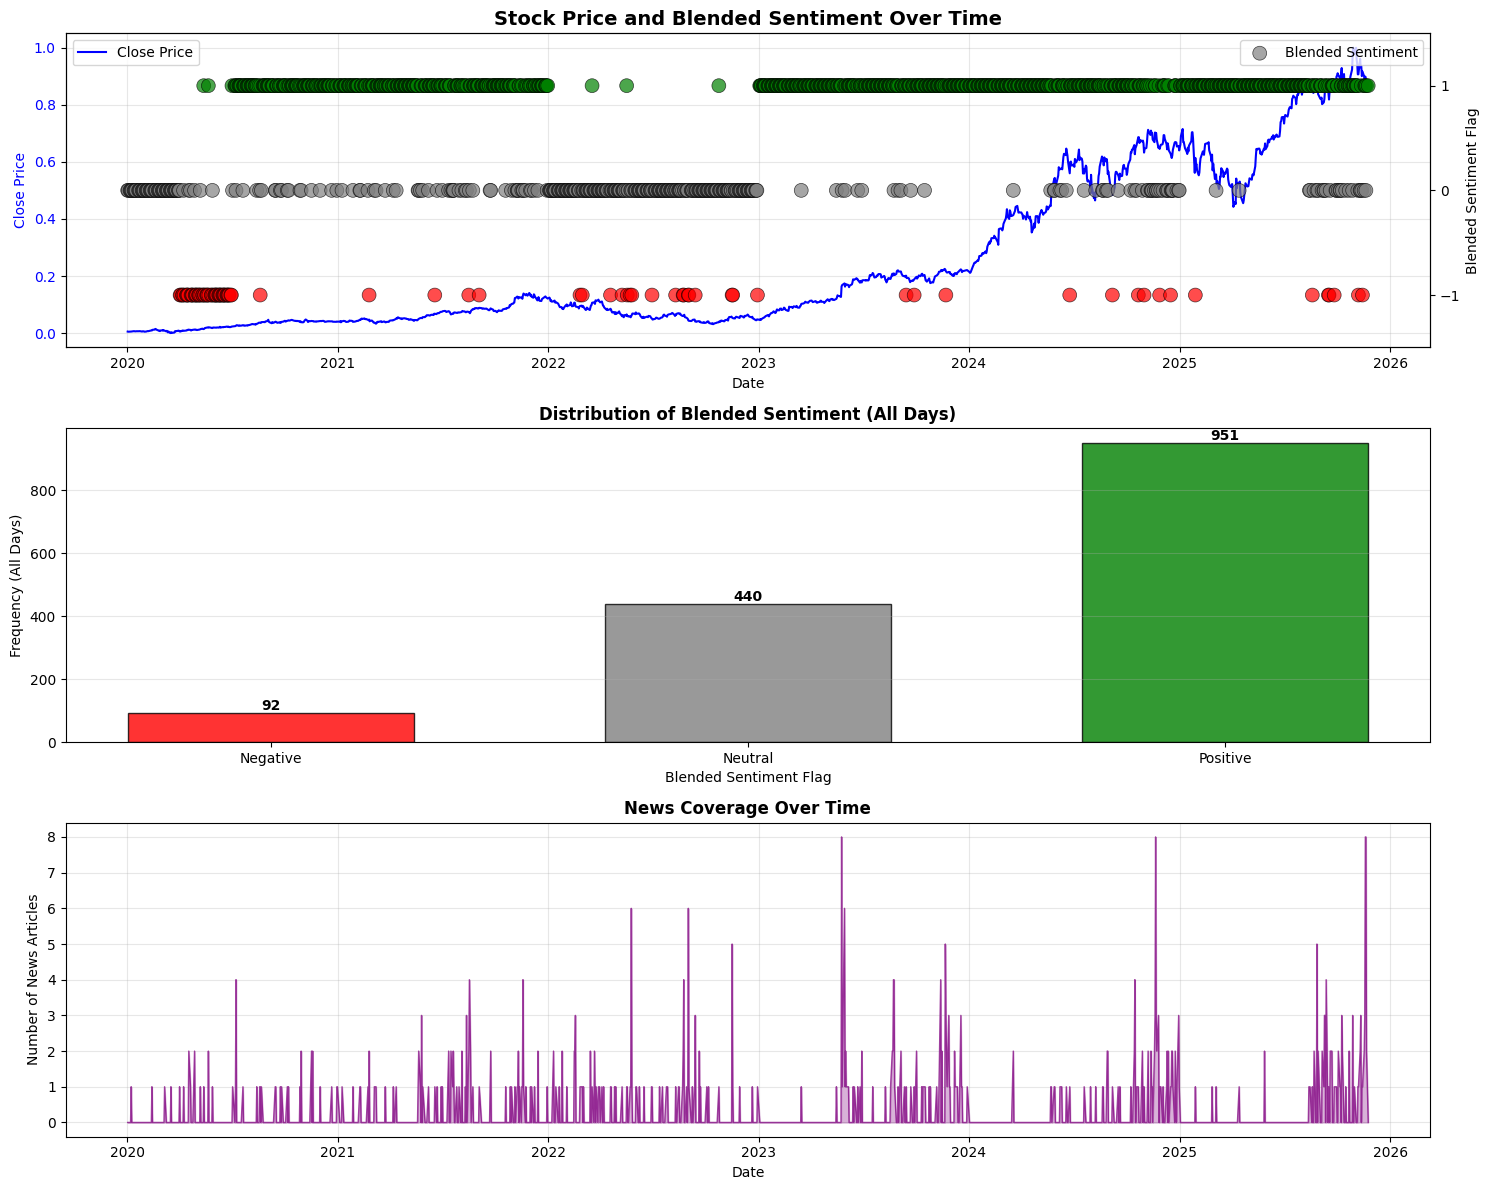


Visualization complete!
Green dots = Positive blended sentiment
Red dots = Negative blended sentiment
Gray dots = Neutral blended sentiment


In [ ]:
# Visualization

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Stock price and blended sentiment for all days
ax1 = axes[0]
ax1.plot(df_with_sentiment['Date'], df_with_sentiment['Close'], label='Close Price', color='blue', linewidth=1.5)
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title('Stock Price and Blended Sentiment Over Time', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
# Color code sentiment based on final_sentiment_flag for all days
colors = df_with_sentiment['final_sentiment_flag'].map({-1: 'red', 0: 'gray', 1: 'green'})
ax2.scatter(df_with_sentiment['Date'], df_with_sentiment['final_sentiment_flag'],
            c=colors, alpha=0.7, s=100, label='Blended Sentiment', edgecolors='black', linewidth=0.5)
ax2.set_ylabel('Blended Sentiment Flag', color='black')
ax2.set_ylim(-1.5, 1.5)
ax2.set_yticks([-1, 0, 1])
ax2.legend(loc='upper right')

# Plot 2: Distribution of Final Blended Sentiment (for all days)
sentiment_counts = df_with_sentiment['final_sentiment_flag'].value_counts().sort_index()
colors_map = {-1: 'red', 0: 'gray', 1: 'green'}
colors = [colors_map.get(idx, 'blue') for idx in sentiment_counts.index]

axes[1].bar(sentiment_counts.index, sentiment_counts.values,
            color=colors, edgecolor='black', width=0.6, alpha=0.8)
axes[1].set_xlabel('Blended Sentiment Flag')
axes[1].set_ylabel('Frequency (All Days)')
axes[1].set_title('Distribution of Blended Sentiment (All Days)', fontsize=12, fontweight='bold')
axes[1].set_xticks([-1, 0, 1])
axes[1].set_xticklabels(['Negative', 'Neutral', 'Positive'])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for idx, val in zip(sentiment_counts.index, sentiment_counts.values):
    axes[1].text(idx, val, str(val), ha='center', va='bottom', fontweight='bold')

# Plot 3: News article count over time
axes[2].plot(df_with_sentiment['Date'], df_with_sentiment['news_article_count'],
             color='purple', linewidth=1, alpha=0.7)
axes[2].fill_between(df_with_sentiment['Date'], df_with_sentiment['news_article_count'],
                      alpha=0.3, color='purple')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Number of News Articles')
axes[2].set_title('News Coverage Over Time', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVisualization complete!")
print(f"Green dots = Positive blended sentiment")
print(f"Red dots = Negative blended sentiment")
print(f"Gray dots = Neutral blended sentiment")


# Training of model

Split dataset into train set and test set

In [ ]:
# Split dataset into train (2020–2024) and test (2025)
df_with_sentiment['Date'] = pd.to_datetime(df_with_sentiment['Date'])
train_df = df_with_sentiment[df_with_sentiment['Date'] < "2025-01-01"].copy()
test_df  = df_with_sentiment[df_with_sentiment['Date'] >= "2025-01-01"].copy()

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (1258, 18)
Test size: (225, 18)


Install Prophet

In [ ]:
# Install Prophet
!pip install --upgrade prophet

Build a machine learning model to predict stock prices using:

Historical price data (Close)

Market sentiment analysis (blended_sentiment_score)

Trading volume (Volume)

In [ ]:
from prophet import Prophet

# Prepare Prophet dataframe (drop news_article_count)
prophet_train = train_df[['Date','Close','blended_sentiment_score','Volume']].copy()
prophet_train.rename(columns={'Date':'ds','Close':'y'}, inplace=True)

# Initialize Prophet
prophet_model = Prophet(daily_seasonality=True, yearly_seasonality=True)
prophet_model.add_regressor('blended_sentiment_score')
prophet_model.add_regressor('Volume')

# Fit
prophet_model.fit(prophet_train)

# Prepare test set for evaluation
prophet_test = test_df[['Date','Close','blended_sentiment_score','Volume']].copy()
prophet_test.rename(columns={'Date':'ds','Close':'y'}, inplace=True)

# Predict on test set
forecast_test = prophet_model.predict(prophet_test)

Systematically test multiple parameter combinations to identify the optimal SARIMAX model for stock price prediction.

In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import itertools

# Define parameter ranges to test
p_values = [0, 1, 2, 3]
d_values = [0, 1, 2]
q_values = [0, 1, 2, 3]

# Generate all combinations
pdq_combinations = list(itertools.product(p_values, d_values, q_values))

# Store results
results = []

# Define target and exogenous variables (drop news_article_count)
y_train = train_df['Close']
X_train = train_df[['blended_sentiment_score', 'Volume']]
y_test = test_df['Close']
X_test = test_df[['blended_sentiment_score', 'Volume']]

print(f"Testing {len(pdq_combinations)} combinations...")

# Grid search
for pdq in pdq_combinations:
    try:
        # Fit model
        model = sm.tsa.SARIMAX(y_train, exog=X_train, order=pdq)
        result = model.fit(disp=False, maxiter=200)

        # Predict
        preds = result.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

        # Calculate metrics
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        # Store result
        results.append({
            'order': pdq,
            'MAE': mae,
            'RMSE': rmse,
            'AIC': result.aic,
            'BIC': result.bic
        })

        print(f"Order {pdq}: MAE={mae:.4f}, RMSE={rmse:.4f}, AIC={result.aic:.2f}")

    except Exception as e:
        print(f"Order {pdq}: Failed - {str(e)}")
        continue

# Find best model by MAE
best_model = min(results, key=lambda x: x['MAE'])
print("\n" + "="*50)
print("BEST MODEL:")
print(f"Order: {best_model['order']}")
print(f"MAE: {best_model['MAE']:.4f}")
print(f"RMSE: {best_model['RMSE']:.4f}")
print(f"AIC: {best_model['AIC']:.2f}")
print(f"BIC: {best_model['BIC']:.2f}")

Testing 48 combinations...
Order (0, 0, 0): MAE=0.4602, RMSE=0.4867, AIC=-892.85
Order (0, 0, 1): MAE=0.5457, RMSE=0.5684, AIC=-2137.39
Order (0, 0, 2): MAE=0.6307, RMSE=0.6499, AIC=-3196.86


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order (0, 0, 3): MAE=0.6980, RMSE=0.7147, AIC=-4134.23
Order (0, 1, 0): MAE=0.1399, RMSE=0.1679, AIC=-8445.74
Order (0, 1, 1): MAE=0.1396, RMSE=0.1675, AIC=-8447.42
Order (0, 1, 2): MAE=0.1399, RMSE=0.1680, AIC=-8451.49
Order (0, 1, 3): MAE=0.1396, RMSE=0.1675, AIC=-8451.13
Order (0, 2, 0): MAE=1.8701, RMSE=2.1986, AIC=-7499.19
Order (0, 2, 1): MAE=0.0846, RMSE=0.1036, AIC=-8434.50
Order (0, 2, 2): MAE=0.0835, RMSE=0.1036, AIC=-8437.02
Order (0, 2, 3): MAE=0.0855, RMSE=0.1039, AIC=-8440.10
Order (1, 0, 0): MAE=0.1495, RMSE=0.1811, AIC=-8442.69
Order (1, 0, 1): MAE=0.1485, RMSE=0.1796, AIC=-8444.35
Order (1, 0, 2): MAE=0.3161, RMSE=0.4002, AIC=-8416.34
Order (1, 0, 3): MAE=0.2289, RMSE=0.2944, AIC=-8437.17
Order (1, 1, 0): MAE=0.1396, RMSE=0.1675, AIC=-8447.93
Order (1, 1, 1): MAE=0.1396, RMSE=0.1675, AIC=-8448.66
Order (1, 1, 2): MAE=0.1397, RMSE=0.1676, AIC=-8452.80
Order (1, 1, 3): MAE=0.1397, RMSE=0.1676, AIC=-8449.87
Order (1, 2, 0): MAE=1.1285, RMSE=1.3453, AIC=-7972.71
Order (1, 

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order (3, 0, 0): MAE=0.1499, RMSE=0.1816, AIC=-8449.15
Order (3, 0, 1): MAE=0.1491, RMSE=0.1805, AIC=-8449.06
Order (3, 0, 2): MAE=0.1405, RMSE=0.1686, AIC=-8456.17


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Order (3, 0, 3): MAE=0.1402, RMSE=0.1682, AIC=-8456.02
Order (3, 1, 0): MAE=0.1396, RMSE=0.1675, AIC=-8452.04
Order (3, 1, 1): MAE=0.1396, RMSE=0.1674, AIC=-8450.04
Order (3, 1, 2): MAE=0.1397, RMSE=0.1677, AIC=-8447.44
Order (3, 1, 3): MAE=0.1396, RMSE=0.1675, AIC=-8447.67
Order (3, 2, 0): MAE=1.0037, RMSE=1.2019, AIC=-8162.29
Order (3, 2, 1): MAE=0.0835, RMSE=0.1037, AIC=-8441.31
Order (3, 2, 2): MAE=0.1070, RMSE=0.1230, AIC=-8447.13
Order (3, 2, 3): MAE=0.1068, RMSE=0.1227, AIC=-8452.08

BEST MODEL:
Order: (2, 2, 2)
MAE: 0.0813
RMSE: 0.1035
AIC: -8436.54
BIC: -8400.59


Build the production-ready forecasting model using the best parameters identified from the previous grid search.

In [ ]:
import statsmodels.api as sm

# Define target and exogenous variables (drop news_article_count)
y_train = train_df['Close']
X_train = train_df[['blended_sentiment_score','Volume']]

# Fit SARIMAX with tuned parameters
sarimax_model = sm.tsa.SARIMAX(y_train, exog=X_train, order=(2,2,2))
sarimax_result = sarimax_model.fit(disp=False)

# Predict on test set
y_test = test_df['Close']
X_test = test_df[['blended_sentiment_score','Volume']]
sarimax_preds = sarimax_result.predict(start=len(y_train), end=len(y_train)+len(y_test)-1, exog=X_test)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Evaluation and export of model

**Evalaution and choosing the best model**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prophet metrics
mae_prophet = mean_absolute_error(prophet_test['y'], forecast_test['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'], forecast_test['yhat']))

# SARIMAX metrics
mae_sarimax = mean_absolute_error(y_test, sarimax_preds)
rmse_sarimax = np.sqrt(mean_squared_error(y_test, sarimax_preds))

print("FINAL MODEL COMPARISON")
print("="*50)
print(f"SARIMAX (tuned) - MAE: {mae_sarimax:.4f}, RMSE: {rmse_sarimax:.4f}")
print(f"Prophet         - MAE: {mae_prophet:.4f}, RMSE: {rmse_prophet:.4f}")
print(f"\nImprovement: {((mae_prophet - mae_sarimax) / mae_prophet * 100):.1f}% better with SARIMAX")

FINAL MODEL COMPARISON
SARIMAX (tuned) - MAE: 0.0826, RMSE: 0.1036
Prophet         - MAE: 0.2136, RMSE: 0.2288

Improvement: 61.3% better with SARIMAX


Best model is exported as best_model.pkl

This model will be integrated into GoSense backend system to build a Stock Forecasting Dashboard

In [ ]:
# Compare RMSE (or MAE) and save best model
if rmse_prophet < rmse_sarimax:
    print("✅ Prophet is more accurate. Saving model...")
    joblib.dump(prophet_model, "best_model.pkl")
else:
    print("✅ SARIMAX is more accurate. Saving model...")
    joblib.dump(sarimax_result, "best_model.pkl")

✅ SARIMAX is more accurate. Saving model...
